
# Project: Investigate a Dataset - [tmdb-movies.csv]

TMDb Movies dataset to understand trends related to movie popularity, revenue, votes, and genres.

# Questions

### How does a movie's budget differentially impact its financial returns (revenue), audience engagement (votes), and cultural reach (popularity), and what does the varying slope of these trends tell us about the predictability of success in the film industry?
### Which movies received the highest number of votes?
### Which movies are the most popular?
### Which genres are the most popular?
### Which movies generated the highest revenue?


#### Importing Necessary Packages 

In [1]:
#importing Packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
!ls #let's check the files present in current directory

Investigate_a_Dataset.html  Investigate_a_Dataset.ipynb  tmdb-movies.csv


In [3]:
# Load your data and print out a few lines. What is the size of your dataframe? 
#   Perform operations to inspect data types and look for instances of missing
#   or possibly errant data. There are at least 4 - 6 methods you can call on your
#   dataframe to obtain this information.
df = pd.read_csv('tmdb-movies.csv')
df.head() #Top 5 rows of the dataset

,id,imdb_id,popularity,budget,revenue,original_title,cast,homepage,director,tagline,...,overview,runtime,genres,production_companies,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj
0,135397,tt0369610,32.985763,150000000,1513528810,Jurassic World,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,http://www.jurassicworld.com/,Colin Trevorrow,The park is open.,...,Twenty-two years after the events of Jurassic ...,124,Action|Adventure|Science Fiction|Thriller,Universal Studios|Amblin Entertainment|Legenda...,6/9/15,5562,6.5,2015,1.379999e+08,1.392446e+09
1,76341,tt1392190,28.419936,150000000,378436354,Mad Max: Fury Road,Tom Hardy|Charlize Theron|Hugh Keays-Byrne|Nic...,http://www.madmaxmovie.com/,George Miller,What a Lovely Day.,...,An apocalyptic story set in the furthest reach...,120,Action|Adventure|Science Fiction|Thriller,Village Roadshow Pictures|Kennedy Miller Produ...,5/13/15,6185,7.1,2015,1.379999e+08,3.481613e+08
2,262500,tt2908446,13.112507,110000000,295238201,Insurgent,Shailene Woodley|Theo James|Kate Winslet|Ansel...,http://www.thedivergentseries.movie/#insurgent,Robert Schwentke,One Choice Can Destroy You,...,Beatrice Prior must confront her inner demons ...,119,Adventure|Science Fiction|Thriller,Summit Entertainment|Mandeville Films|Red Wago...,3/18/15,2480,6.3,2015,1.012000e+08,2.716190e+08
3,140607,tt2488496,11.173104,200000000,2068178225,Star Wars: The Force Awakens,Harrison Ford|Mark Hamill|Carrie Fisher|Adam D...,http://www.starwars.com/films/star-wars-episod...,J.J. Abrams,Every generation has a story.,...,Thirty years after defeating the Galactic Empi...,136,Action|Adventure|Science Fiction|Fantasy,Lucasfilm|Truenorth Productions|Bad Robot,12/15/15,5292,7.5,2015,1.839999e+08,1.902723e+09
4,168259,tt2820852,9.335014,190000000,1506249360,Furious 7,Vin Diesel|Paul Walker|Jason Statham|Michelle ...,http://www.furious7.com/,James Wan,Vengeance Hits Home,...,Deckard Shaw seeks revenge against Dominic Tor...,137,Action|Crime|Thriller,Universal Pictures|Original Film|Media Rights ...,4/1/15,2947,7.3,2015,1.747999e+08,1.385749e+09


In [4]:
# Checked the summary of the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10866 entries, 0 to 10865
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    10866 non-null  int64  
 1   imdb_id               10856 non-null  object 
 2   popularity            10866 non-null  float64
 3   budget                10866 non-null  int64  
 4   revenue               10866 non-null  int64  
 5   original_title        10866 non-null  object 
 6   cast                  10790 non-null  object 
 7   homepage              2936 non-null   object 
 8   director              10822 non-null  object 
 9   tagline               8042 non-null   object 
 10  keywords              9373 non-null   object 
 11  overview              10862 non-null  object 
 12  runtime               10866 non-null  int64  
 13  genres                10843 non-null  object 
 14  production_companies  9836 non-null   object 
 15  release_date       

## Data Cleaning

##### Dropping NA values

In [5]:
# removing the NA values from imdb_id and cast coloumns
df.dropna(subset=['imdb_id', 'cast'], inplace=True)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 10780 entries, 0 to 10865
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    10780 non-null  int64  
 1   imdb_id               10780 non-null  object 
 2   popularity            10780 non-null  float64
 3   budget                10780 non-null  int64  
 4   revenue               10780 non-null  int64  
 5   original_title        10780 non-null  object 
 6   cast                  10780 non-null  object 
 7   homepage              2906 non-null   object 
 8   director              10746 non-null  object 
 9   tagline               8013 non-null   object 
 10  keywords              9324 non-null   object 
 11  overview              10777 non-null  object 
 12  runtime               10780 non-null  int64  
 13  genres                10760 non-null  object 
 14  production_companies  9795 non-null   object 
 15  release_date       

## Exploratory Data Analysis

### Checking Duplicates

In [7]:
#analysing the imdb_id primary key
df['imdb_id'].info()

<class 'pandas.core.series.Series'>
Int64Index: 10780 entries, 0 to 10865
Series name: imdb_id
Non-Null Count  Dtype 
--------------  ----- 
10780 non-null  object
dtypes: object(1)
memory usage: 168.4+ KB


In [8]:
# as imdb_id must be primary key so there should be no Duplicacy 
df['imdb_id'].duplicated().any()

True

In [9]:
#checking which imdb_id is having duplicates
df[df['imdb_id'].duplicated()]['imdb_id']

2090    tt0411951
Name: imdb_id, dtype: object

In [10]:
# checked the whole row for the duplicated imdb_id
df[df['imdb_id'].duplicated(keep=False)]

,id,imdb_id,popularity,budget,revenue,original_title,cast,homepage,director,tagline,...,overview,runtime,genres,production_companies,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj
2089,42194,tt0411951,0.59643,30000000,967000,TEKKEN,Jon Foo|Kelly Overton|Cary-Hiroyuki Tagawa|Ian...,NaN,Dwight H. Little,Survival is no game,...,"In the year of 2039, after World Wars destroy ...",92,Crime|Drama|Action|Thriller|Science Fiction,Namco|Light Song Films,3/20/10,110,5.0,2010,30000000.0,967000.0
2090,42194,tt0411951,0.59643,30000000,967000,TEKKEN,Jon Foo|Kelly Overton|Cary-Hiroyuki Tagawa|Ian...,NaN,Dwight H. Little,Survival is no game,...,"In the year of 2039, after World Wars destroy ...",92,Crime|Drama|Action|Thriller|Science Fiction,Namco|Light Song Films,3/20/10,110,5.0,2010,30000000.0,967000.0


In [11]:
#removing the duplicates from the imdb_id permanently 
df.drop_duplicates(subset=['imdb_id'], inplace=True)

In [12]:
# checking whether we have removed the dupliacates or not ?
#False = no duplicates
#True = having Duplicates
df['imdb_id'].duplicated().any()

False

In [13]:
# let's again check the column imdb_id summary #10780 -> 10779 (because only 1 duplicate was there)
df['imdb_id'].info()

<class 'pandas.core.series.Series'>
Int64Index: 10779 entries, 0 to 10865
Series name: imdb_id
Non-Null Count  Dtype 
--------------  ----- 
10779 non-null  object
dtypes: object(1)
memory usage: 168.4+ KB


In [14]:
# Checking the duplicity for all the columns present 
df.apply(lambda col: col.duplicated().sum())

id                          0
imdb_id                     0
popularity                 47
budget                  10226
revenue                  6081
original_title            292
cast                       69
homepage                 7911
director                 5753
tagline                  2810
keywords                 2017
overview                   16
runtime                 10532
genres                   8750
production_companies     3354
release_date             4888
vote_count               9490
vote_average            10709
release_year            10723
budget_adj               8173
revenue_adj              5943
dtype: int64

#### no duplicates on id & imdb_id

### let's manage our columns efficiently 


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 10779 entries, 0 to 10865
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    10779 non-null  int64  
 1   imdb_id               10779 non-null  object 
 2   popularity            10779 non-null  float64
 3   budget                10779 non-null  int64  
 4   revenue               10779 non-null  int64  
 5   original_title        10779 non-null  object 
 6   cast                  10779 non-null  object 
 7   homepage              2906 non-null   object 
 8   director              10745 non-null  object 
 9   tagline               8012 non-null   object 
 10  keywords              9323 non-null   object 
 11  overview              10776 non-null  object 
 12  runtime               10779 non-null  int64  
 13  genres                10759 non-null  object 
 14  production_companies  9794 non-null   object 
 15  release_date       

In [16]:
df.describe()

,id,popularity,budget,revenue,runtime,vote_count,vote_average,release_year,budget_adj,revenue_adj
count,10779.000000,10779.000000,1.077900e+04,1.077900e+04,10779.000000,10779.000000,10779.000000,10779.000000,1.077900e+04,1.077900e+04
mean,65539.338436,0.650336,1.473889e+07,4.014136e+07,102.380740,218.913721,5.967446,2001.280546,1.768734e+07,5.177567e+07
std,91701.376608,1.003155,3.101050e+07,1.174205e+08,30.963167,577.681865,0.931775,12.817885,3.440928e+07,1.451420e+08
min,5.000000,0.000065,0.000000e+00,0.000000e+00,0.000000,10.000000,1.500000,1960.000000,0.000000e+00,0.000000e+00
25%,10562.500000,0.209792,0.000000e+00,0.000000e+00,90.000000,17.000000,5.400000,1995.000000,0.000000e+00,0.000000e+00
50%,20465.000000,0.385600,0.000000e+00,0.000000e+00,99.000000,38.000000,6.000000,2006.000000,0.000000e+00,0.000000e+00
75%,74581.000000,0.718740,1.600000e+07,2.471342e+07,112.000000,147.000000,6.600000,2011.000000,2.103337e+07,3.425268e+07
max,417859.000000,32.985763,4.250000e+08,2.781506e+09,900.000000,9767.000000,9.200000,2015.000000,4.250000e+08,2.827124e+09


In [17]:
#So from above statistical summary 
""" we can change the followings:- 
release_year olumn max value is 2015 so we can change the datatype as (int16)
vote_average column max value is 9.2 we can change the dataype as (float32)
vote_count column max value is 9767 we can change the dataype as (int16)
runtime column max value is 900 we can change the dataype as (int16)
popularity column max value is 32.98 we can change the dataype as (float32) """

' we can change the followings:- \nrelease_year olumn max value is 2015 so we can change the datatype as (int16)\nvote_average column max value is 9.2 we can change the dataype as (float32)\nvote_count column max value is 9767 we can change the dataype as (int16)\nruntime column max value is 900 we can change the dataype as (int16)\npopularity column max value is 32.98 we can change the dataype as (float32) '

In [18]:
df['release_year'] = df['release_year'].astype("int16")
df['vote_average'] = df['vote_average'].astype("float32")
df['vote_count'] = df['vote_count'].astype("int16")
df['runtime'] = df['runtime'].astype("int16")
df['popularity'] = df['vote_average'].astype("float32")

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 10779 entries, 0 to 10865
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    10779 non-null  int64  
 1   imdb_id               10779 non-null  object 
 2   popularity            10779 non-null  float32
 3   budget                10779 non-null  int64  
 4   revenue               10779 non-null  int64  
 5   original_title        10779 non-null  object 
 6   cast                  10779 non-null  object 
 7   homepage              2906 non-null   object 
 8   director              10745 non-null  object 
 9   tagline               8012 non-null   object 
 10  keywords              9323 non-null   object 
 11  overview              10776 non-null  object 
 12  runtime               10779 non-null  int16  
 13  genres                10759 non-null  object 
 14  production_companies  9794 non-null   object 
 15  release_date       

#### Decreased in the Size from 1.8Mb to 1.5

### How does a movie's budget differentially impact its financial returns (revenue), audience engagement (votes), and cultural reach (popularity), and what does the varying slope of these trends tell us about the predictability of success in the film industry?

In [20]:
# to check the correlation let's check the datatype all should be numeric
df[['budget', 'revenue', 'vote_count', 'popularity']].dtypes

budget          int64
revenue         int64
vote_count      int16
popularity    float32
dtype: object

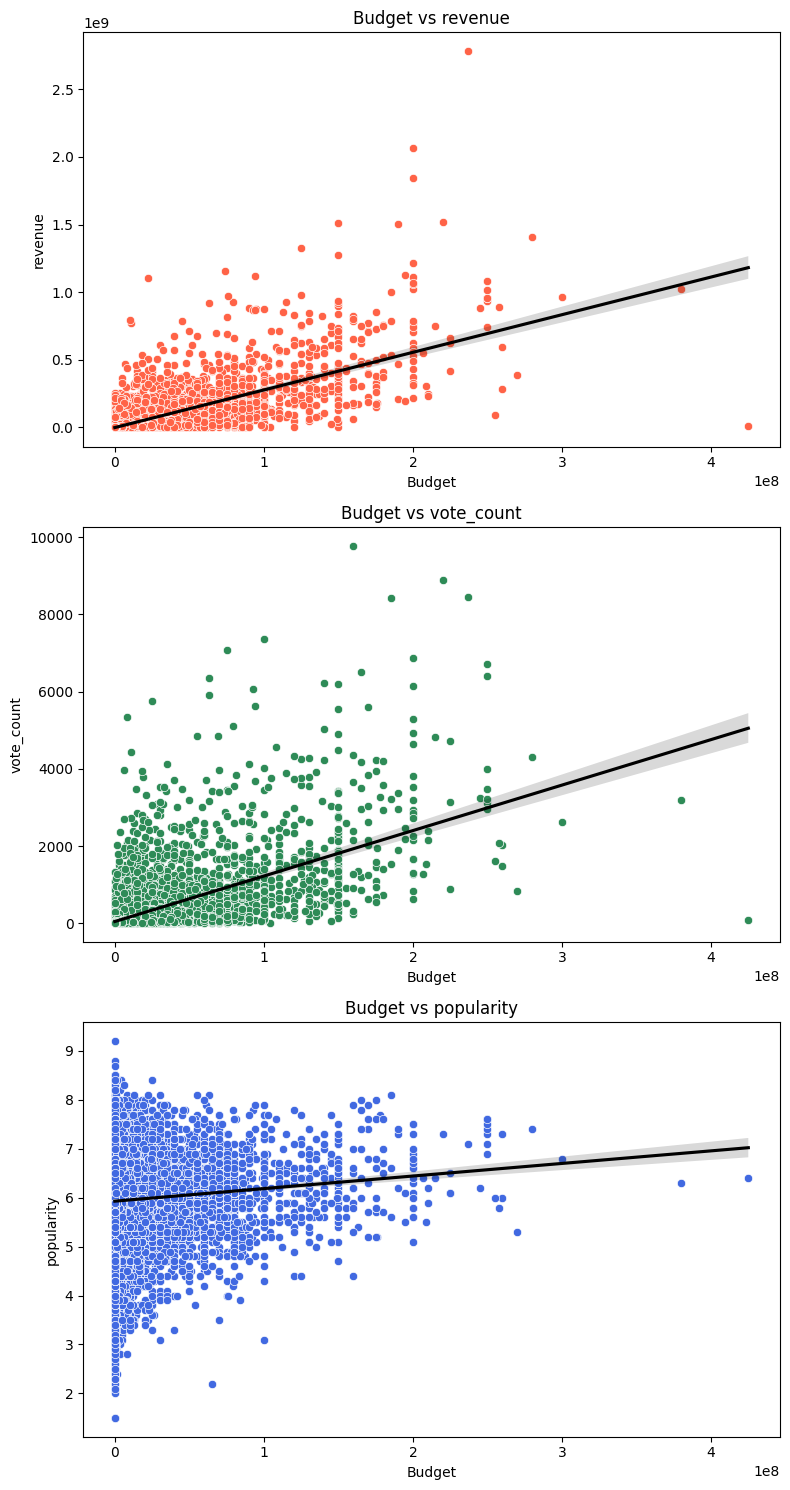

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = ['revenue', 'vote_count', 'popularity']
colors = ['tomato', 'seagreen', 'royalblue']

fig, axes = plt.subplots(3, 1, figsize=(8, 15))

for ax, col, color in zip(axes, cols, colors):
    sns.scatterplot(data=df, x='budget', y=col, color=color, ax=ax)
    sns.regplot(data=df, x='budget', y=col, scatter=False, color='black', ax=ax)
    ax.set_title(f'Budget vs {col}')
    ax.set_xlabel('Budget')
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

### Relationship Regression Slope Key Data Insight (The "Why")Budget vs. Revenue Highly Steep Strong Financial Returns: There is a strong positive correlation here. As the budget increases, revenue tends to grow significantly. This suggests that high-investment movies (blockbusters) generally yield higher box-office collections.

### Budget vs. Vote Count Moderate / Average Engagement vs. Investment: A higher budget leads to more audience engagement (votes), likely due to wider distribution and marketing. However, the correlation isn't as tight as revenue, meaning high spending doesn't always guarantee a high volume of viewers.

### Budget vs. Popularity Flat / Low Organic Appeal: The horizontal nature of the line indicates that Popularity cannot be bought. High-budget films and low-budget films have almost equal chances of trending. Popularity is driven by content quality and viral factors, not just production cost.

### Most voted top 10 Movies

In [22]:
movies_with_most_votes = df.groupby(df['original_title'])['vote_count'].sum()
movies_with_most_votes = movies_with_most_votes.sort_values(ascending=False).head(10)
movies_with_most_votes.nunique()
movies_with_most_votes = (
    df.groupby(df['original_title'])['vote_count']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
print(movies_with_most_votes)

original_title
Inception                            9767
The Avengers                         9024
Avatar                               8458
The Dark Knight                      8432
Django Unchained                     7375
The Hunger Games                     7080
Iron Man 3                           6882
The Dark Knight Rises                6723
Interstellar                         6498
The Hobbit: An Unexpected Journey    6417
Name: vote_count, dtype: int16


<function matplotlib.pyplot.show(close=None, block=None)>

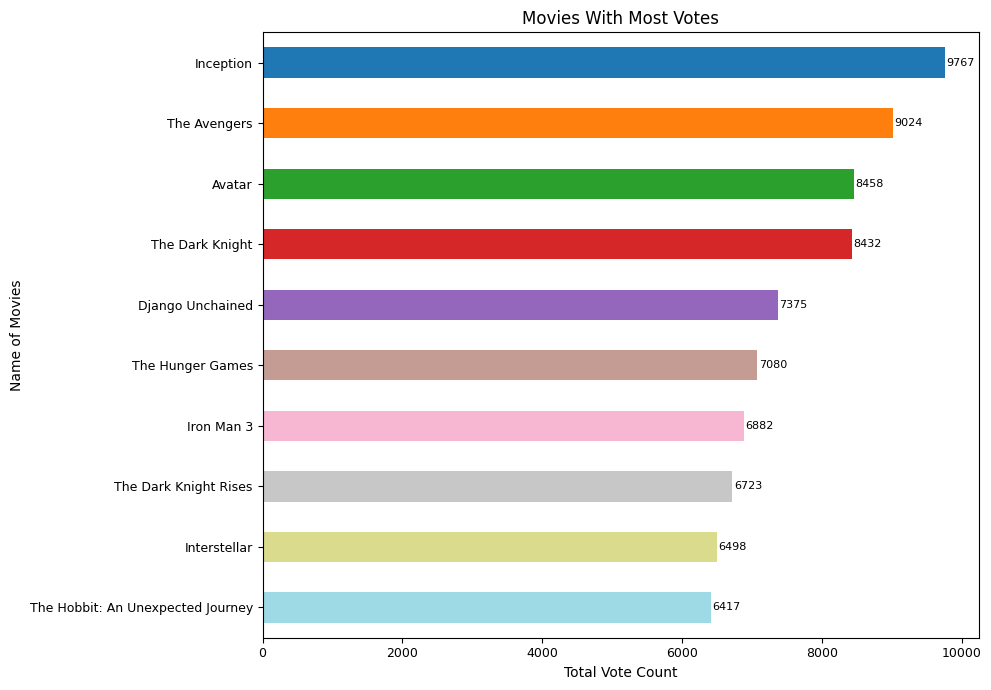

In [23]:
#Visualisation for the Most voted top 10 Movies
counts = 10
plot_colors = plt.cm.tab20(np.linspace(0, 1, counts))

# creating a plot function for the reuse 
def plot_barh(df, title="My Chart", colors=None):
    # horizontal bar logic
    ax = df.plot(
        kind='barh',
        figsize=(10, 7),
        fontsize=9,
        color='skyblue' if colors is None else colors
    )
    plt.title(title)
    return ax

ax = plot_barh(movies_with_most_votes, title="Movies With Most Votes", colors=plot_colors)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=1, fontsize=8)

    
ax.invert_yaxis() #highest value highest value at top
plt.xlabel('Total Vote Count')
plt.ylabel('Name of Movies')
plt.tight_layout()
plt.show

#### Top 10 Movies having more popularity

In [24]:
movies_with_most_popularity = (
    df.groupby(df['original_title'])['popularity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
movies_with_most_popularity

original_title
Hamlet                  24.600000
Emma                    20.700001
Wuthering Heights       20.000000
Beauty and the Beast    19.900000
Life                    19.500000
A Christmas Carol       19.299999
Alice in Wonderland     18.799999
Jane Eyre               18.500000
Shelter                 18.400000
Oliver Twist            18.400000
Name: popularity, dtype: float32

<function matplotlib.pyplot.show(close=None, block=None)>

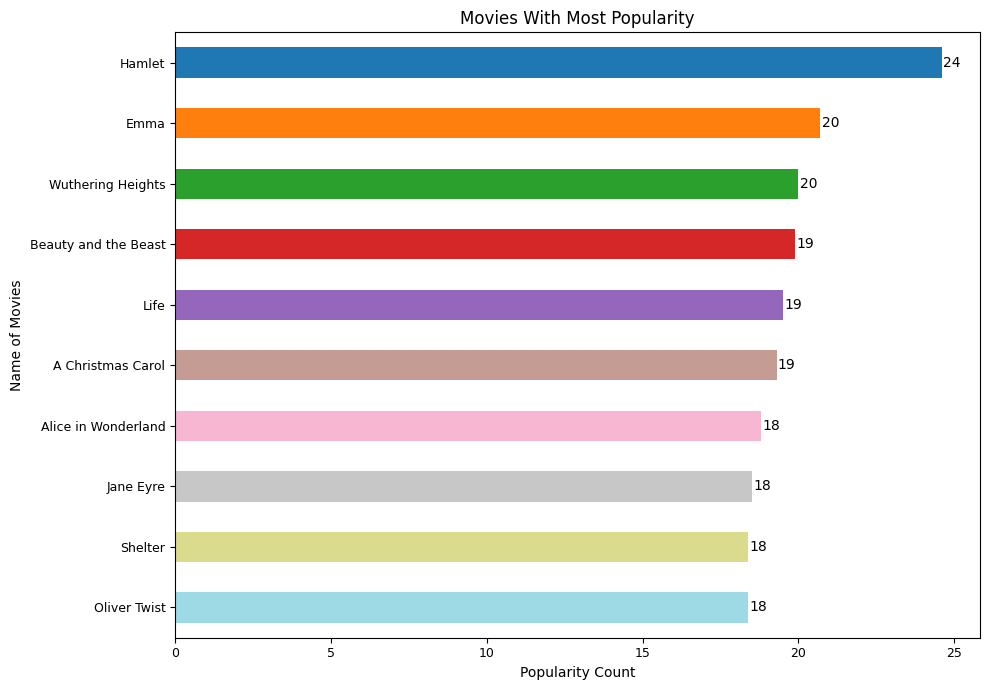

In [25]:
# Viusualisation for Top 10 Movies having more popularity
counts = 10
plot_colors = plt.cm.tab20(np.linspace(0, 1, counts))

ax = plot_barh(movies_with_most_popularity, title="Movies With Most Popularity", colors=plot_colors)
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=1, fontsize=10)
    
ax.invert_yaxis() #highest value highest value at top
plt.xlabel('Popularity Count')
plt.ylabel('Name of Movies')
plt.tight_layout()
plt.show

### Top 10 Genres are having more popularity

In [26]:
genres_with_most_popularity = (
    df.groupby('genres')['popularity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

genres_with_most_popularity

genres
Drama                   4493.100098
Comedy                  4144.600098
Documentary             1911.500000
Drama|Romance           1810.800049
Comedy|Drama            1719.800049
Comedy|Romance          1556.199951
Horror|Thriller         1376.099976
Comedy|Drama|Romance    1350.199951
Horror                  1298.300049
Drama|Thriller           820.099976
Name: popularity, dtype: float32

<function matplotlib.pyplot.show(close=None, block=None)>

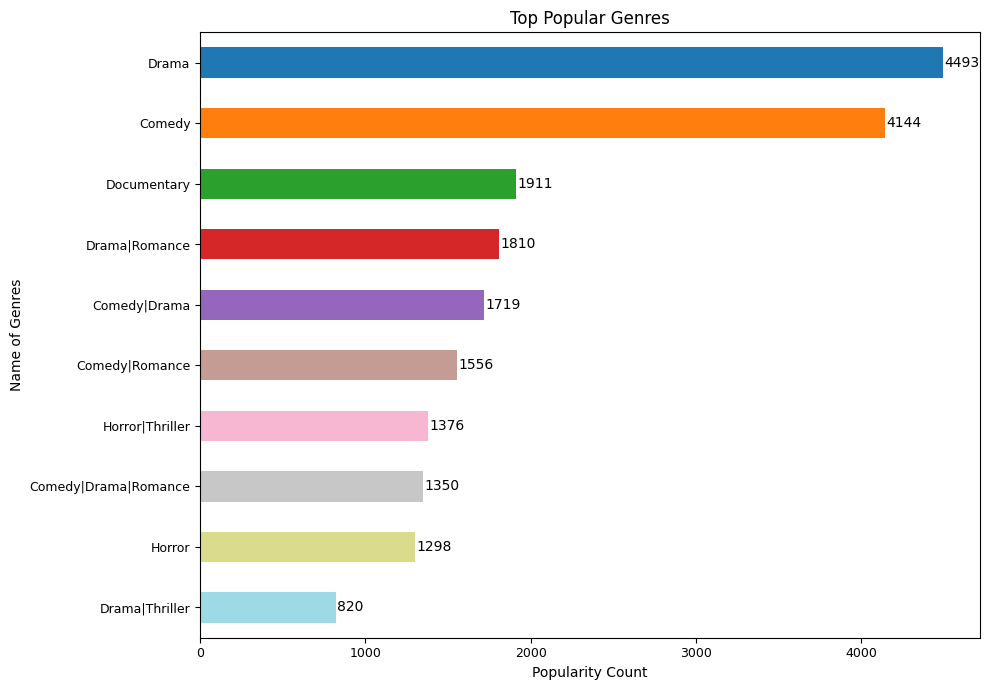

In [27]:
# Viusualisation for Top 10 Genres having more popularity
counts = 10
plot_colors = plt.cm.tab20(np.linspace(0, 1, counts))

ax = plot_barh(genres_with_most_popularity, title="Top Popular Genres", colors=plot_colors)
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=1, fontsize=10)
    
ax.invert_yaxis() #highest value at top
plt.xlabel('Popularity Count')
plt.ylabel('Name of Genres')
plt.tight_layout()
plt.show

### Top 10 Movies generated more revenue

In [28]:
# Continue to explore the data to address your additional research
#   questions. Add more headers as needed if you have more questions to
#   investigate.
movies_with_most_revenue = (
    df.groupby('original_title')['revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

movies_with_most_revenue

original_title
Avatar                                          2781505847
Star Wars: The Force Awakens                    2068178225
Titanic                                         1845034188
The Avengers                                    1568080742
Jurassic World                                  1513528810
Furious 7                                       1506249360
Avengers: Age of Ultron                         1405035767
Harry Potter and the Deathly Hallows: Part 2    1327817822
Frozen                                          1277284869
Iron Man 3                                      1215439994
Name: revenue, dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

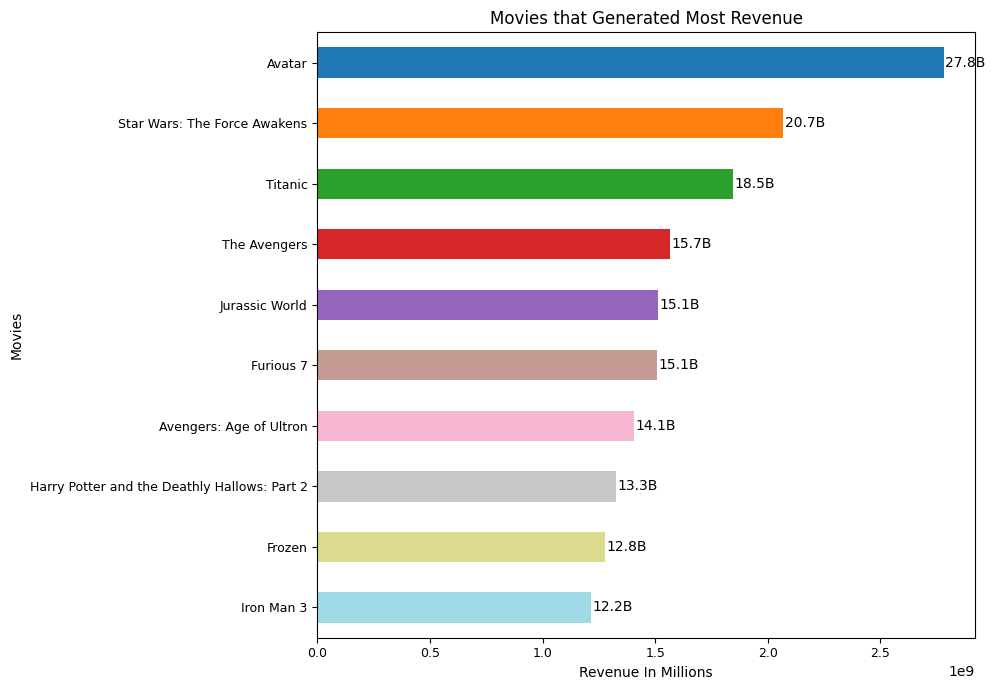

In [29]:
# Top 10 Movies generated more revenue
counts = 10
plot_colors = plt.cm.tab20(np.linspace(0, 1, counts))

ax = plot_barh(movies_with_most_revenue, title="Movies that Generated Most Revenue", colors=plot_colors)
for container in ax.containers:
    labels = [f'{v/1_000_000_00:.1f}B' for v in container.datavalues]
    ax.bar_label(container, labels=labels, fmt='%d', padding=1, fontsize=10)
    
ax.invert_yaxis() #highest value at top
plt.xlabel('Revenue In Millions')
plt.ylabel('Movies')
plt.tight_layout()
plt.show

## Conclusions

### Based on the analysis,
### Relationship Regression Slope Key Data Insight (The "Why")Budget vs. Revenue Highly Steep Strong Financial Returns: There is a strong positive correlation here. As the budget increases, revenue tends to grow significantly. This suggests that high-investment movies (blockbusters) generally yield higher box-office collections.

### Budget vs. Vote Count Moderate / Average Engagement vs. Investment: A higher budget leads to more audience engagement (votes), likely due to wider distribution and marketing. However, the correlation isn't as tight as revenue, meaning high spending doesn't always guarantee a high volume of viewers.

### Budget vs. Popularity Flat / Low Organic Appeal: The horizontal nature of the line indicates that Popularity cannot be bought. High-budget films and low-budget films have almost equal chances of trending. Popularity is driven by content quality and viral factors, not just production cost.

### Inception received the highest number of votes.
### Hamlet emerged as the most popular movie
### Drama is the most popular genre overall
### and Avatar generated the highest revenue.

### Limitations of the Analysis
1.Dataset Constraints
Financial fields (budget, revenue) may contain missing or inaccurate entries.
Important factors such as marketing spend, critic reviews, regional performance, and streaming impact are not included.<br>
2.Temporal Bias<br>
Inflation and ticket price changes over time are not adjusted.
Older movies may suffer from lower votes due to platform evolution.<br>
3.Popularity Metric Bias
TMDb popularity is a composite score and may not fully reflect real-world popularity.
It blends social and platform-based signals.<br>
4.Genre Classification
Multi-genre movies are not separated, causing potential overlap in genre-level analysis.<br>
5.Correlation vs Causation
Relationships observed are correlational, not causal.
Regression models do not capture nonlinear or interaction effects.<br>
6.Visualization Scope
High-level plots may hide trends in subgroups such as country, runtime, or release decade.

In [30]:
# Running this cell will execute a bash command to convert this notebook to an .html file
!python -m nbconvert --to html Investigate_a_Dataset.ipynb

[NbConvertApp] Converting notebook Investigate_a_Dataset.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 5 image(s).
[NbConvertApp] Writing 796824 bytes to Investigate_a_Dataset.html
